> **Exploratory Data Analysis of Indian Sectoral Indices Using**

**Project Objective:**
The objective of this project is to perform exploratory data analysis (EDA) on major Indian sectoral indices between January 2021 and 2026 using Python. The project aims to analyze sector-wise performance, volatility, return behavior, and inter-sector relationships through statistical analysis and data visualization techniques.

**Selected Sectoral Indices**


*   NIFTY BANK
*   NIFTY IT
*   NIFTY FMCG
*   NIFTY PHARMA
*   NIFTY AUTO

**Tools & Libraries Used**

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* yfinance
* Google Colab

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

**Importing Data**

In [10]:
# Dictionary of sectoral indices

tickers = {"Bank": "^NSEBANK",
           "IT": "^CNXIT",
           "FMCG": "^CNXFMCG",
           "Pharma": "^CNXPHARMA",
           "Auto": "^CNXAUTO"}

In [12]:
# Download historical daily data

indices_data = yf.download(list(tickers.values()),
                           start="2021-01-01",
                           end="2026-05-22")

indices_data

/tmp/ipykernel_1110/1543030625.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  indices_data = yf.download(list(tickers.values()),
[*********************100%***********************]  5 of 5 completed


Price              Close                                            \
Ticker          ^CNXAUTO      ^CNXFMCG        ^CNXIT    ^CNXPHARMA   
Date                                                                 
2021-01-01           NaN           NaN  24456.099609  13001.950195   
2021-01-04   9417.950195  34619.699219  25110.050781  13149.799805   
2021-01-05   9416.049805  34720.250000  25769.150391  13166.349609   
2021-01-06   9379.549805  34327.351562  25419.150391  13118.099609   
2021-01-07   9429.650391  34032.351562  25251.199219  13060.750000   
...                  ...           ...           ...           ...   
2026-05-15  26070.699219  51051.351562  27716.900391  24634.800781   
2026-05-18  25624.300781  50900.101562  28389.800781  24762.849609   
2026-05-19  25698.800781  50883.351562  29308.000000  24867.400391   
2026-05-20  25914.349609  50520.550781  29185.150391  24843.150391   
2026-05-21  25986.250000  50263.550781  29021.099609  24890.900391   

Price                             High                              \
Ticker          ^NSEBANK      ^CNXAUTO      ^CNXFMCG        ^CNXIT   
Date                                                                 
2021-01-01  31225.486328           NaN           NaN  24500.699219   
2021-01-04  31212.085938   9434.349609  34713.601562  25158.849609   
2021-01-05  31721.880859   9431.000000  34788.351562  25824.150391   
2021-01-06  31797.531250   9484.049805  34768.199219  26036.699219   
2021-01-07  31955.628906   9530.599609  34543.000000  25702.300781   
...                  ...           ...           ...           ...   
2026-05-15  53710.351562  26357.900391  51440.199219  28114.099609   
2026-05-18  53537.000000  25921.099609  50987.050781  28466.099609   
2026-05-19  53409.148438  25962.150391  51467.648438  29609.599609   
2026-05-20  53562.199219  26007.349609  50657.699219  29517.150391   
2026-05-21  53439.398438  26235.199219  50901.601562  29328.349609   

Price                                   ...          Open                \
Ticker        ^CNXPHARMA      ^NSEBANK  ...      ^CNXAUTO      ^CNXFMCG   
Date                                    ...                               
2021-01-01  13045.549805  31383.984484  ...           NaN           NaN   
2021-01-04  13186.549805  31489.233102  ...   9346.150391  34535.250000   
2021-01-05  13247.049805  31767.280722  ...   9356.900391  34473.500000   
2021-01-06  13205.650391  31981.929500  ...   9424.500000  34748.101562   
2021-01-07  13200.250000  32177.026726  ...   9453.650391  34521.648438   
...                  ...           ...  ...           ...           ...   
2026-05-15  24847.900391  54325.449219  ...  26131.349609  50848.851562   
2026-05-18  24788.949219  53667.550781  ...  25909.300781  50973.800781   
2026-05-19  25001.250000  53770.648438  ...  25680.449219  50920.199219   
2026-05-20  25043.150391  53640.898438  ...  25538.900391  50564.699219   
2026-05-21  25001.000000  54109.148438  ...  26147.699219  50800.800781   

Price                                                    Volume           \
Ticker            ^CNXIT    ^CNXPHARMA      ^NSEBANK   ^CNXAUTO ^CNXFMCG   
Date                                                                       
2021-01-01  24300.199219  12933.099609  31296.936669        NaN      NaN   
2021-01-04  24612.050781  13085.299805  31484.783935  1641300.0  44400.0   
2021-01-05  25057.650391  13148.049805  31040.738395  1361400.0  36400.0   
2021-01-06  25841.300781  13181.000000  31839.579590  1301900.0  72800.0   
2021-01-07  25692.050781  13168.450195  32129.427669  1620000.0  56100.0   
...                  ...           ...           ...        ...      ...   
2026-05-15  27472.650391  24644.949219  54207.750000  1044400.0  39200.0   
2026-05-18  27689.599609  24617.000000  53282.148438   568000.0  34000.0   
2026-05-19  28679.849609  24771.300781  53553.750000   707400.0  41400.0   
2026-05-20  29140.800781  24807.050781  53015.699219   987500.0  31600.0   

In [15]:
# Extract Adjusted Close prices only

indices = indices_data["Close"]
indices

Ticker,^CNXAUTO,^CNXFMCG,^CNXIT,^CNXPHARMA,^NSEBANK
Date,,,,,
2021-01-01,NaN,NaN,24456.099609,13001.950195,31225.486328
2021-01-04,9417.950195,34619.699219,25110.050781,13149.799805,31212.085938
2021-01-05,9416.049805,34720.250000,25769.150391,13166.349609,31721.880859
2021-01-06,9379.549805,34327.351562,25419.150391,13118.099609,31797.531250
2021-01-07,9429.650391,34032.351562,25251.199219,13060.750000,31955.628906
...,...,...,...,...,...
2026-05-15,26070.699219,51051.351562,27716.900391,24634.800781,53710.351562
2026-05-18,25624.300781,50900.101562,28389.800781,24762.849609,53537.000000
2026-05-19,25698.800781,50883.351562,29308.000000,24867.400391,53409.148438


In [17]:
# Rename columns

indices.columns = ["Auto", "FMCG", "IT", "Pharma", "Bank"]
indices

,Auto,FMCG,IT,Pharma,Bank
Date,,,,,
2021-01-01,NaN,NaN,24456.099609,13001.950195,31225.486328
2021-01-04,9417.950195,34619.699219,25110.050781,13149.799805,31212.085938
2021-01-05,9416.049805,34720.250000,25769.150391,13166.349609,31721.880859
2021-01-06,9379.549805,34327.351562,25419.150391,13118.099609,31797.531250
2021-01-07,9429.650391,34032.351562,25251.199219,13060.750000,31955.628906
...,...,...,...,...,...
2026-05-15,26070.699219,51051.351562,27716.900391,24634.800781,53710.351562
2026-05-18,25624.300781,50900.101562,28389.800781,24762.849609,53537.000000
2026-05-19,25698.800781,50883.351562,29308.000000,24867.400391,53409.148438


**Initial Data Exploration:**
This section examines the structure, quality, and statistical properties of the dataset before performing exploratory data analysis.

In [20]:
indices.shape

(1328, 5)

In [21]:
indices.columns

Index(['Auto', 'FMCG', 'IT', 'Pharma', 'Bank'], dtype='object')

In [22]:
indices.head()

,Auto,FMCG,IT,Pharma,Bank
Date,,,,,
2021-01-01,NaN,NaN,24456.099609,13001.950195,31225.486328
2021-01-04,9417.950195,34619.699219,25110.050781,13149.799805,31212.085938
2021-01-05,9416.049805,34720.250000,25769.150391,13166.349609,31721.880859
2021-01-06,9379.549805,34327.351562,25419.150391,13118.099609,31797.531250
2021-01-07,9429.650391,34032.351562,25251.199219,13060.750000,31955.628906


In [23]:
indices.tail()

,Auto,FMCG,IT,Pharma,Bank
Date,,,,,
2026-05-15,26070.699219,51051.351562,27716.900391,24634.800781,53710.351562
2026-05-18,25624.300781,50900.101562,28389.800781,24762.849609,53537.000000
2026-05-19,25698.800781,50883.351562,29308.000000,24867.400391,53409.148438
2026-05-20,25914.349609,50520.550781,29185.150391,24843.150391,53562.199219
2026-05-21,25986.250000,50263.550781,29021.099609,24890.900391,53439.398438


In [28]:
indices.isnull().sum()

,0
Auto,15
FMCG,15
IT,0
Pharma,1
Bank,0


In [26]:
indices.duplicated().sum()

np.int64(0)

In [ ]:
# Observation: The dataset contains a small number of missing values, primarily in the Auto and FMCG indices. Since the missing observations represent a very
# small proportion of the total dataset, they will be handled using forward fill to preserve continuity in the time series.

In [34]:
indices.fillna(method = "ffill", inplace = True)
indices.fillna(method = "bfill", inplace = True)


/tmp/ipykernel_1110/3903767368.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  indices.fillna(method = "ffill", inplace = True)
/tmp/ipykernel_1110/3903767368.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  indices.fillna(method = "ffill", inplace = True)
/tmp/ipykernel_1110/3903767368.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  indices.fillna(method = "bfill", inplace = True)
/tmp/ipykernel_1110/3903767368.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.h

In [36]:
indices.isnull().sum().sum()

np.int64(0)

In [37]:
indices

,Auto,FMCG,IT,Pharma,Bank
Date,,,,,
2021-01-01,9417.950195,34619.699219,24456.099609,13001.950195,31225.486328
2021-01-04,9417.950195,34619.699219,25110.050781,13149.799805,31212.085938
2021-01-05,9416.049805,34720.250000,25769.150391,13166.349609,31721.880859
2021-01-06,9379.549805,34327.351562,25419.150391,13118.099609,31797.531250
2021-01-07,9429.650391,34032.351562,25251.199219,13060.750000,31955.628906
...,...,...,...,...,...
2026-05-15,26070.699219,51051.351562,27716.900391,24634.800781,53710.351562
2026-05-18,25624.300781,50900.101562,28389.800781,24762.849609,53537.000000
2026-05-19,25698.800781,50883.351562,29308.000000,24867.400391,53409.148438


**Daily Return Analysis:**
This section analyzes the daily percentage returns of selected Indian sectoral indices to study return behavior, volatility, and comparative sector performance. Logarithmic returns were used instead of simple percentage returns because they are additive over time and commonly used in quantitative financial analysis.

In [41]:
log_returns = np.log(indices / indices.shift(1))
log_returns

,Auto,FMCG,IT,Pharma,Bank
Date,,,,,
2021-01-01,NaN,NaN,NaN,NaN,NaN
2021-01-04,0.000000,0.000000,0.026389,0.011307,-0.000429
2021-01-05,-0.000202,0.002900,0.025910,0.001258,0.016201
2021-01-06,-0.003884,-0.011381,-0.013675,-0.003671,0.002382
2021-01-07,0.005327,-0.008631,-0.006629,-0.004381,0.004960
...,...,...,...,...,...
2026-05-15,0.000806,0.005346,0.012947,0.003405,-0.007763
2026-05-18,-0.017271,-0.002967,0.023988,0.005184,-0.003233
2026-05-19,0.002903,-0.000329,0.031831,0.004213,-0.002391


In [42]:
log_returns.dropna(inplace = True)
log_returns

,Auto,FMCG,IT,Pharma,Bank
Date,,,,,
2021-01-04,0.000000,0.000000,0.026389,0.011307,-0.000429
2021-01-05,-0.000202,0.002900,0.025910,0.001258,0.016201
2021-01-06,-0.003884,-0.011381,-0.013675,-0.003671,0.002382
2021-01-07,0.005327,-0.008631,-0.006629,-0.004381,0.004960
2021-01-08,0.032510,0.007156,0.035450,0.016011,0.004004
...,...,...,...,...,...
2026-05-15,0.000806,0.005346,0.012947,0.003405,-0.007763
2026-05-18,-0.017271,-0.002967,0.023988,0.005184,-0.003233
2026-05-19,0.002903,-0.000329,0.031831,0.004213,-0.002391


**Comparative Sector Performance:**
This section compares the relative performance of selected Indian sectoral indices over the analysis period using normalized index values.

In [44]:
#Normalizing index returns

normalized_indices = (indices / indices.iloc[0]) * 100
normalized_indices

,Auto,FMCG,IT,Pharma,Bank
Date,,,,,
2021-01-01,100.000000,100.000000,100.000000,100.000000,100.000000
2021-01-04,100.000000,100.000000,102.673980,101.137134,99.957085
2021-01-05,99.979822,100.290444,105.369011,101.264421,101.589710
2021-01-06,99.592264,99.155545,103.937876,100.893323,101.831981
2021-01-07,100.124233,98.303429,103.251130,100.452238,102.338290
...,...,...,...,...,...
2026-05-15,276.819251,147.463302,113.333282,189.470044,172.008055
2026-05-18,272.079383,147.026412,116.084745,190.454887,171.452894
2026-05-19,272.870426,146.978029,119.839224,191.259004,171.043448


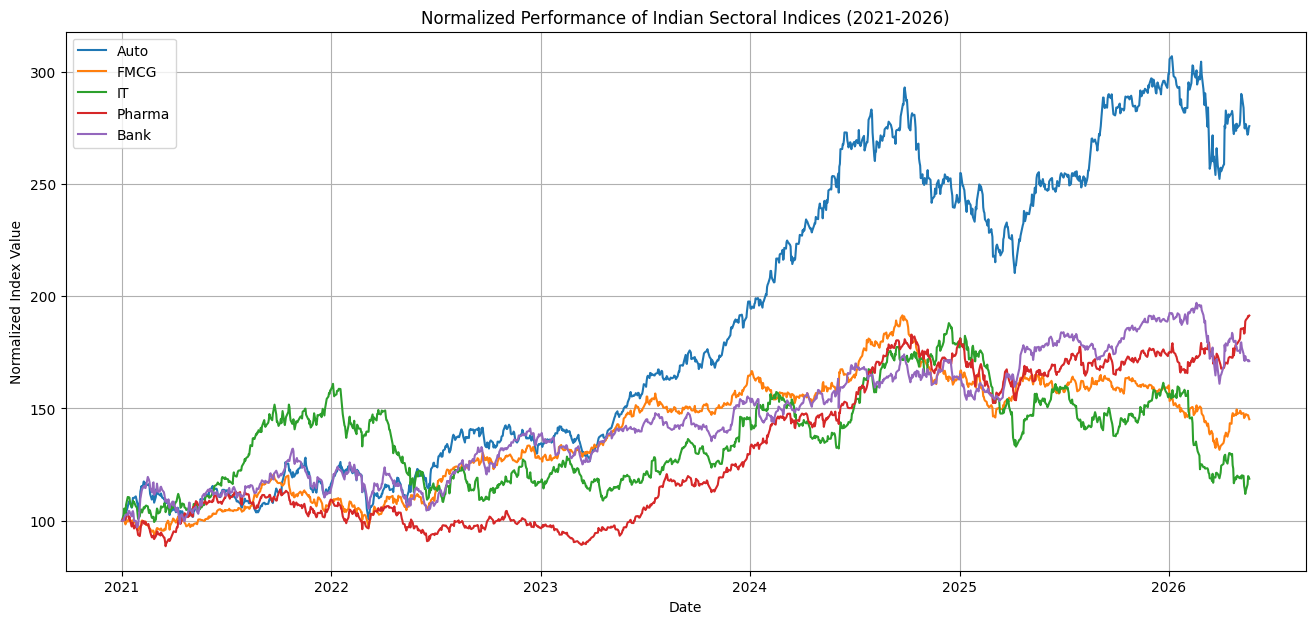

In [80]:
plt.figure(figsize=(16,7))

for column in normalized_indices.columns:
    plt.plot(normalized_indices.index,
             normalized_indices[column],
             label = column)

plt.title("Normalized Performance of Indian Sectoral Indices (2021-2026)")
plt.xlabel("Date")
plt.ylabel("Normalized Index Value")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Insights:
#1. NIFTY AUTO emerged as the strongest performing sector during the analysis period.
#2. NIFTY FMCG exhibited comparatively stable performance with lower fluctuations.
#3. NIFTY IT experienced strong early growth followed by periods of correction.
#4. Banking and Pharma sectors demonstrated relatively consistent long-term growth trends.

**Volatility Analysis:**
This section evaluates the volatility of selected Indian sectoral indices using logarithmic daily returns. Volatility measures the degree of fluctuation in returns and serves as a proxy for market risk.

In [79]:
vlt = log_returns.std() * np.sqrt(252) * 100
vlt

,0
Auto,19.923122
FMCG,13.920239
IT,21.530159
Pharma,15.762436
Bank,18.311855


/tmp/ipykernel_1110/3874074380.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  vol_bars = sns.barplot(x = vlt.index,


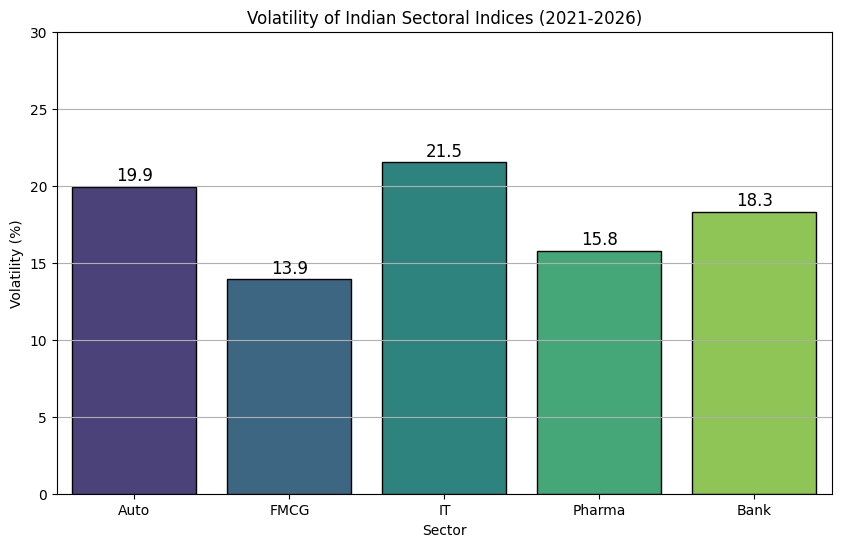

In [77]:
plt.figure(figsize = (10,6))

vol_bars = sns.barplot(x = vlt.index,
            y = vlt.values,
            palette = "viridis",
            edgecolor = "black")

plt.title("Volatility of Indian Sectoral Indices (2021-2026)")
plt.xlabel("Sector")
plt.ylabel("Volatility (%)")
plt.ylim(0, 30)
plt.grid(axis = "y")

for bar in vol_bars.patches:
    vol_bars.annotate(format(bar.get_height(), '.1f'),
                 (bar.get_x() + bar.get_width() / 2,
                  bar.get_height()), ha = 'center', va = 'center',
                 size = 12, xytext = (0, 8),
                 textcoords = 'offset points')

plt.show()

In [ ]:
# Insights:
#1. NIFTY IT exhibited the highest volatility, indicating the greatest fluctuations and highest market risk among the selected sectors.
#2. NIFTY FMCG showed the lowest volatility, making it the most stable and defensive sector during the analysis period.
#3. NIFTY AUTO combined high volatility with strong cumulative returns, reflecting a high-risk, high-return relationship.
#4. Overall, cyclical sectors such as IT and Auto were more volatile, while defensive sectors such as FMCG and Pharma displayed relatively stable return behavior.

**Correlation Analysis:**
This section analyzes the correlation between sectoral index returns to examine how different sectors move relative to each other during the analysis period.

In [82]:
cr = log_returns.corr()
cr

,Auto,FMCG,IT,Pharma,Bank
Auto,1.000000,0.508489,0.374269,0.465701,0.637438
FMCG,0.508489,1.000000,0.339534,0.388907,0.429449
IT,0.374269,0.339534,1.000000,0.375294,0.344056
Pharma,0.465701,0.388907,0.375294,1.000000,0.350435
Bank,0.637438,0.429449,0.344056,0.350435,1.000000


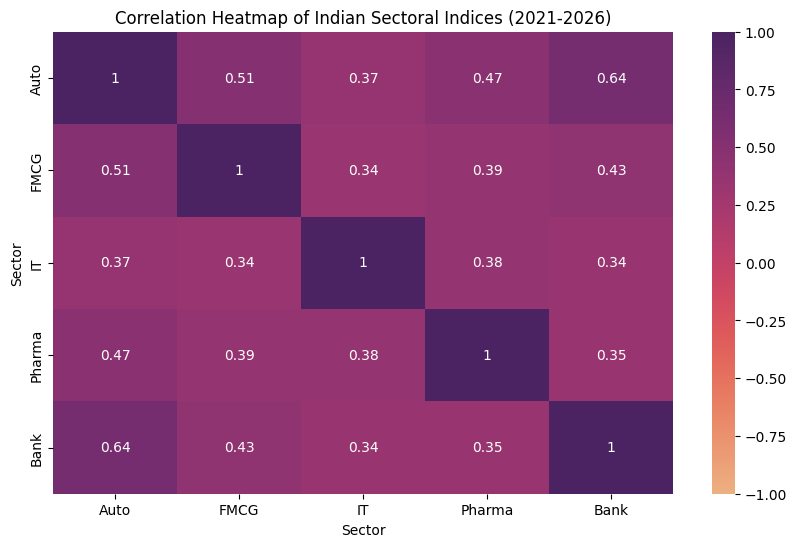

In [102]:
plt.figure(figsize = (10,6))

sns.heatmap(cr, cmap = "flare", annot = True, vmin = -1, vmax = 1)

plt.title("Correlation Heatmap of Indian Sectoral Indices (2021-2026)")
plt.xlabel("Sector")
plt.ylabel("Sector")
plt.show()

In [ ]:
# Insights:
#1. Most sectoral indices exhibited moderate positive correlations, indicating that sectors generally moved in the same direction as the broader market while still maintaining distinct sector-specific behavior.
#2. NIFTY AUTO and NIFTY BANK showed the strongest positive correlation (~0.64), suggesting that both sectors were similarly influenced by macroeconomic conditions and market sentiment.
#3. NIFTY IT displayed comparatively lower correlations with other sectors, indicating relatively independent movement patterns and potential diversification benefits.
#4. Defensive sectors such as FMCG and Pharma exhibited moderate correlations with cyclical sectors, reflecting comparatively stable market behavior during the analysis period.
#5. The absence of extremely high correlations suggests that sector diversification may help reduce overall portfolio risk.

**Rolling Volatility Analysis:**
This section analyzes the changing volatility of sectoral index returns over time using rolling annualized volatility.

In [120]:
rolling_vlt = log_returns.rolling(window = 120).std() * np.sqrt(252) * 100
rolling_vlt


,Auto,FMCG,IT,Pharma,Bank
Date,,,,,
2021-01-04,NaN,NaN,NaN,NaN,NaN
2021-01-05,NaN,NaN,NaN,NaN,NaN
2021-01-06,NaN,NaN,NaN,NaN,NaN
2021-01-07,NaN,NaN,NaN,NaN,NaN
2021-01-08,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2026-05-15,25.188817,16.640283,25.696884,15.776348,20.536829
2026-05-18,25.302277,16.627996,25.943619,15.753007,20.539870
2026-05-19,25.303585,16.627427,26.010871,15.761128,20.521357


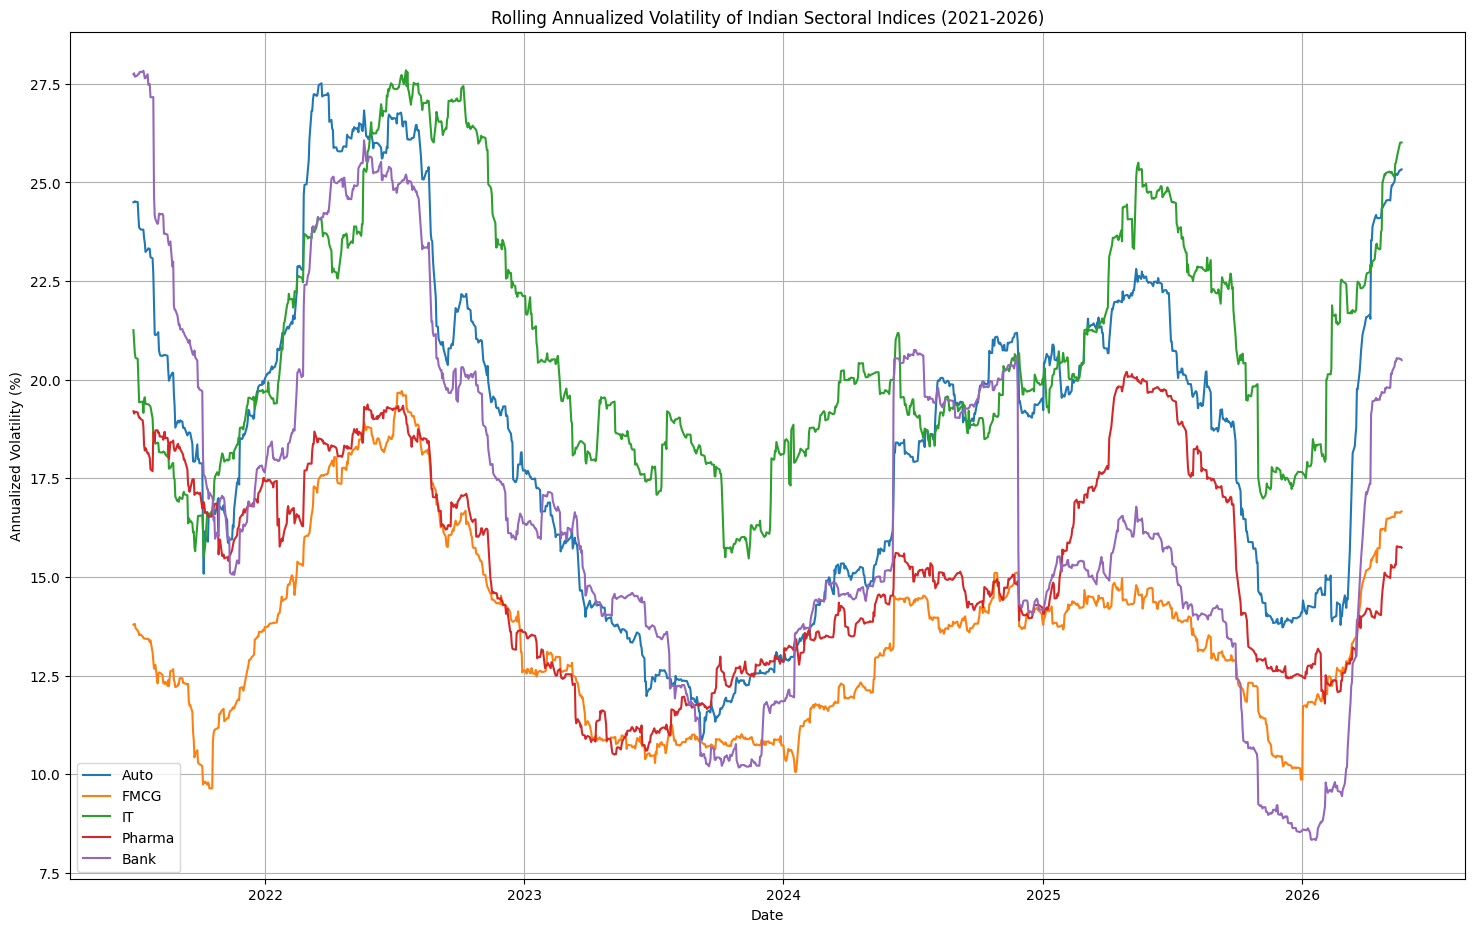

In [121]:
plt.figure(figsize = (18,11))

for column in rolling_vlt.columns:
    plt.plot(rolling_vlt.index,
             rolling_vlt[column],
             label = column)

plt.xlabel("Date")
plt.ylabel("Annualized Volatility (%)")
plt.title("Rolling Annualized Volatility of Indian Sectoral Indices (2021-2026)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Insights
#1. NIFTY IT maintained relatively high rolling volatility across multiple periods, indicating persistent fluctuations and higher sector-specific risk during the analysis period.
#2. NIFTY FMCG exhibited the most stable volatility pattern, reinforcing its defensive nature and comparatively lower market sensitivity.
#3. NIFTY AUTO experienced significant volatility swings, reflecting the cyclical behavior of the automobile sector and changing economic conditions.
#4. NIFTY BANK showed notable shifts in volatility regimes, suggesting sensitivity to macroeconomic trends and interest rate expectations.
#5. Several sectors experienced simultaneous increases in volatility during certain periods, indicating broader market-wide uncertainty and volatility clustering effects.

**Risk vs Return Analysis (Risk-Return Tradeoff):**
This section compares annualized returns and annualized volatility of selected Indian sectoral indices to evaluate the relationship between risk and return across sectors.

In [124]:
ann_returns = np.exp(log_returns.mean() * 252) - 1
ann_returns_pct = ann_returns * 100
ann_returns_pct

,0
Auto,21.256880
FMCG,7.337336
IT,3.303440
Pharma,13.124969
Bank,10.742439


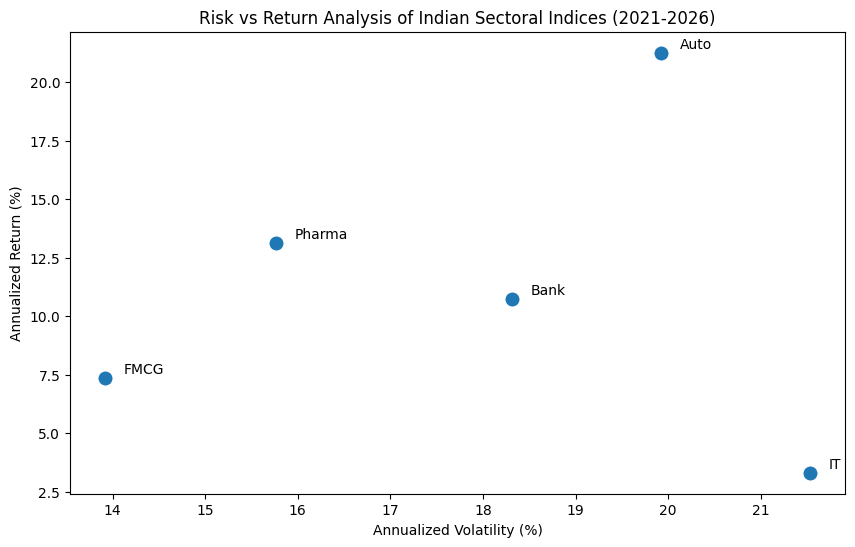

In [145]:
plt.figure(figsize = (10,6))

sns.scatterplot(x = vlt, y = ann_returns_pct, s = 120)

for sector in vlt.index:
    plt.text(vlt[sector] + 0.2,
             ann_returns_pct[sector] + 0.2,
             sector)

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Annualized Return (%)")
plt.title("Risk vs Return Analysis of Indian Sectoral Indices (2021-2026)")
plt.show()

In [ ]:
# Insights
#1. NIFTY AUTO delivered the highest returns alongside high volatility, reflecting a strong risk-return relationship.
#2. NIFTY FMCG showed the lowest volatility and comparatively stable return behavior, consistent with its defensive nature.
#3. NIFTY IT exhibited the highest volatility but relatively weak returns, indicating that higher risk does not always result in higher performance.
#4. NIFTY PHARMA demonstrated a relatively balanced risk-return profile with moderate volatility and strong returns.

> **Conclusion**


This project analyzed the performance, volatility, correlation, and risk-return characteristics of major Indian sectoral indices between 2021 and 2026 using Python-based exploratory data analysis techniques.

* NIFTY AUTO emerged as the strongest performing sector, delivering the highest cumulative and annualized returns during the analysis period.
* NIFTY FMCG exhibited the lowest volatility and the most stable return behavior, reflecting its defensive nature.
* NIFTY IT showed relatively high volatility but comparatively weaker returns, highlighting that higher risk does not always guarantee superior performance.
* Correlation analysis indicated moderate positive relationships among sectors, suggesting potential diversification benefits across sectoral investments.
* Rolling volatility analysis revealed changing market risk regimes and periods of volatility clustering across sectors.

Overall, the project demonstrates how sectoral behavior differs across market conditions and highlights the importance of balancing return expectations with risk considerations in financial analysis and portfolio decision-making.